# AnaEE Weather Data Access API

In this notebook we show how to invoke a simple weather data access service hosted by [AnaEE](https://anaee.eu).

## Setting up the environment

+ Install dependencies
+ Create Environmental Variables

These operations must be done *once*: after you install dependencies and declare environment variables, they will be there forever and you will only have to import them to allow your code to use them.

### Installing dependencies

In what follows, the exclamation mark `!` is used to send command directly to the Operating System. The following command installs the required dependencies detailed in the `requirements.txt` file present in the project root folder. Put the cursor in the following cell and press the `Run` button:

In [1]:
! pip install -r requirements.txt


[notice] A new release of pip available: 22.3 -> 22.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Right now you should have all the required dependencies *installed* on your interpreter, but they are not yet *visible*, i.e., your code does not know where to find them. To be able to use them, you need to *import* them as follows:

In [15]:
import os
import re
import requests
from io import BytesIO, StringIO
import pandas as pd
import json
import shapely
import matplotlib.pyplot as plt
import shapely.wkt


If the above cell raised an error, it means that something went wrong while installing the dependencies.

### Setting up the API personal key
This is the key provided by the [Developer Portal](https://developer.anaee.eu/) when the relative subscription is activated. It must be included in every request sent to the APIs.

The best way to use personal keys is to store them as environment variables in the Operative System, so all programs installed should be able to read them, with no need of explicitly writing them in the code or configuration files. There are different ways to set an environment variables:
+ Windows: go to Properties -> System and look for `Advanced System Settings in Windows`, at the bottom of the dialog there is a button named Environmental Variables, click it and add the required variable. Alteratively, this can be done by opening a cmd prompt and type `setx NAME "VALUE"` and the variable will be visible to all subsequent sessions (i.e. you should close that command prompt).
+ Linux: run in your shell `export NAME=VALUE`

If running under Windows, replace `"your api key"` with the correct value and run the following cell:

In [1]:
!setx ANAEE_API_KEY "your-api-key"


SUCCESS: Specified value was saved.


The jupyter server must now be restarted (also the cmd), to make the new environment variable visible.

If are running under LINUX, replace `your api key` with the correct value and run the following cell:

In [4]:
!export ANAEE_API_KEY=your-api-key

'export' is not recognized as an internal or external command,
operable program or batch file.


Now the relevant variables can be made available to the code in this notebook:

In [16]:
SERVICE_KEY = os.environ['ANAEE_API_KEY']

# Calling the API
We are going to use RESTful Web Services, i.e. machine-operable services that are on the internet and work with http protocol that is the same used by Web browsers.

In [17]:
SERVICE_URL = 'https://api.anaee.eu/crea-aa-dailymeteo'

## Writing a remote service access method
Consuming a Web Service requires a little coding effort that we can wrap up in a function to call anytime we need to ask something to the API. This will make the code way more easy to maintain and to read. Following are technical details on such a function.

Defining a function in Python is staightforward: start with the keyword `def`, than enter the name of the function, and its arguments between brackets. Finally put a colon at the end of the argument declaration.
We are defining the function with several arguments with *default values*. Python allows default values for function arguments.

RESTful Web services are stateless services that are exposed on the Web and auctionable with an *http* request, i.e. the same technology Web browsers use to request web pages and applications. The *stateless* bit is referred to the *communication protocol* between the client and the server (in this case the API) and it means that the client-server communication is constrained by no client context being stored on the server between requests. The practical implication is that if two distinct clients make the *very same request* at a certain time they will receive the same response. On the other hand the server can be stateful, for instance it may have a database and present users with different results over time as its data is updated.

RESTful Web Services use JSON as data exchange format: they expect the Client to send requests in JSON form, and in return they give their response in JSON formats. In Python JSON objects are mapped into Dictionaries, which are a primitive type. Dictionaries are made like this:
```
{ 
    key_1: value_1,
    key_2: value_2,
    ...
    key:n : value_n
}
```
Where keys and values can be objects of any type, with only two major restrictions:
+ A given key can appear in a dictionary only once. Duplicate keys are not allowed. A dictionary maps each key to a corresponding value, so it doesn’t make sense to map a particular key more than once. If a key is specified a second time during the initial creation of a dictionary, then the second occurrence will override the first.
+ A dictionary key must be of a type that is *immutable*. For example, we can use an integer, float, string, datetime, or Boolean as a dictionary key. However, neither a list nor another dictionary can serve as a dictionary key, because lists and dictionaries are mutable. Values, on the other hand, can be any type and can be used more than once.

Dictionaries can be naturally converted to JSON objects and vice versa, and we will leverage this feature to build our request function.

Python comes with a library named `requests` that allows to make http requests with ease. We will need to:
+ set authentication properties, i.e. the API key, in the request header.
+ "dump" the request dictionary into a JSON object.
+ invoke the Web service, and read its status.
+ If the request has been successful, we can parse the JSON response into a dictionary and return it. Some requests may have a non-JSON response. In such a case, the response will be converted into a string. If it is impossible to convert the response into a string, we will print a warning and return a None object.
+ If the request failed, we will print a warning and return and return a None object.

The following function implements these steps.

In [18]:
def call_restful_api(function, data={}, base_url=SERVICE_URL, key=SERVICE_KEY, method='POST'):
    '''
    Calls a RESTful API
        Parameters:
            function (string): the name of the API method to invoke
            data (dictionary): the data payload
            bas_url (string): the base addres of the API
            key (string): the service key you registered
            method(string): the HTTP method you want to use, defaults to POST

        Returns:
            service response (str or dictionary): Web service response, either a dictionary or a string.
    
    '''
    # set request headers    
    headers = {'Content-Type': 'application/json'}
    headers['Ocp-Apim-Subscription-Key'] = key
    # serialize request data into a json object
    payload = json.dumps(data)
    response = None
    # invoke the Web Service
    if method == 'POST':
        response = requests.post(base_url + '/' + function, data=payload, headers=headers)
    else:
        response=requests.get(base_url + '/' + function, data=payload, headers=headers)
    if response.status_code == 200: # the 200 status means 'success'
        try:
            return response.json() 
        except:
            try:
                return response.text
            except:
                print('Unable to decode server response')
    else:
        print('Request failed with code ' + str(response.status_code))
    return None

The call to the Web Service is done by the following line:
```
response = requests.post(base_url + '/' + function, data=payload, headers=headers)

```
Where `payload` is the request JSON object, and `headers` is a dictionary of headers that, in our case, includes the content type of the body and the authentication key. Such a call returns a Response object that has three objects of interest:
+ the Response code: an HTTP code, 200 means "ok", 404 is "not found, check the URL", 403 means "wrong key, probably you are not worthy of using the system", 401 means "invalid or utterly moronic request", and 50X that something very bad occurred server side;
+ the elapsed time;
+ the response object, which can be interpreted as a string or as a dictionary.

Depending on the reponse code and response object type, the above function returns either a string, a dictionary or a None object.

## The Weather Data API
The weather data API has four *methods*, you can see their details [here](https://developer.anaee.eu/api-details#api=crea-aa-italian-historical-wheater-series), they are:
+ `getNearestRasterData`: it gets the nearest raster point data to a given geometry;
+ `getNearestStationData`: it gets the station data within a certain geometry;
+ `getRasterData`: it gets the raster point data within a certain geometry;
+ `getStationData`: it gets the station data within a certain geometry;

The *interface* for all four methods includes the following parameters:
+ `startTime`: the start date of the weather data series, by default it's a month ago;
+ `endTime`: the end of the weather data series, by default it's right now;
+ `timeStep`: if we'd like daily or hourly data, by defautl it's "daily";
+ `wkt`: the area of interest expressed in [WGS84](https://en.wikipedia.org/wiki/World_Geodetic_System) coordinates, as a [WKT](https://en.wikipedia.org/wiki/Well-known_text_representation_of_geometry) polygon. Mind that when specifying a polygon, vertices must be specified in counter-clockwise order;
+ `mode`: the desired output format, it can be either "csv", "json", or "bioma"; by default it's "csv".

Let's make some proactical examples. First of all, let's specify a WKT polygon and let's plot it to make sure it is properly delcared.

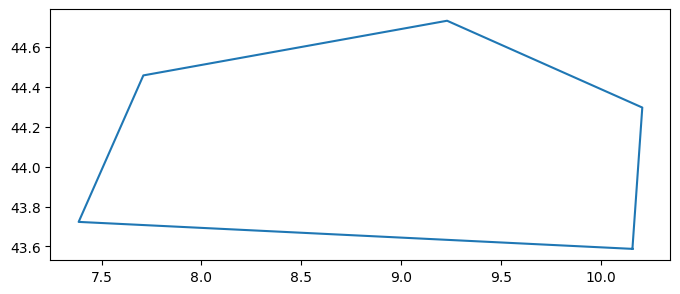

In [19]:
polygon_string = "POLYGON((10.15905865446625 43.58782080564057,10.20849713102875 44.29581102576821,9.23071392790375 44.73060761735282,7.709107482591251 44.45678937969159,7.385010802903751 43.72294797699299,10.15905865446625 43.58782080564057))"

# let's visualize it
P = shapely.wkt.loads(polygon_string)
plt.figure(figsize=(8,5))
plt.axes().set_aspect('equal')
plt.plot(*P.exterior.xy)
plt.show()

If you check the coordinates, you'll see that the above polygon includes the Liguria region. We can use it to retrieve all data that sits in that region.

Let's now build the *request* object, which will include the start time, the end time, and the timestep along with the geographic boundaries.

In [20]:
data = {"startTime":"2022-06-14",
"endTime":"2022-06-20",
"timeStep":"hour",
"wkt":polygon_string
}
# call the service
r = call_restful_api('getStationData', data,key = SERVICE_KEY, base_url = SERVICE_URL, method= 'POST')
# read the response into a data table
day_data = pd.read_csv(StringIO(r))
day_data

,date,seriesID,averageTemp,maxTemp,minTemp,windSpeed,maxWindSpeed,windGust,precipitation,stationPressure,...,RHMin,RHMax,RAD,leafWetness,idGroup,idCode,stationName,country,elevation,geography
0,2022-06-14 00:00:00+02:00,11,19.4,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,regione-liguria,AGORR,Alpe Gorreto,IT,915.0,POINT (9.2363 44.6047)
1,2022-06-14 01:00:00+02:00,11,19.1,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,regione-liguria,AGORR,Alpe Gorreto,IT,915.0,POINT (9.2363 44.6047)
2,2022-06-14 02:00:00+02:00,11,14.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,regione-liguria,AGORR,Alpe Gorreto,IT,915.0,POINT (9.2363 44.6047)
3,2022-06-14 03:00:00+02:00,11,18.6,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,regione-liguria,AGORR,Alpe Gorreto,IT,915.0,POINT (9.2363 44.6047)
4,2022-06-14 04:00:00+02:00,11,17.9,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,regione-liguria,AGORR,Alpe Gorreto,IT,915.0,POINT (9.2363 44.6047)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22723,2022-06-19 20:00:00+02:00,10,29.7,30.4,29.0,1.4,5.1,NaN,0.0,981.8,...,NaN,NaN,NaN,0.0,regione-piemonte,295,CastagnoleLanze,IT,624.0,POINT (7.682172984478326 44.306248995776635)
22724,2022-06-19 21:00:00+02:00,10,28.2,28.9,27.5,1.7,5.5,NaN,0.0,979.1,...,NaN,NaN,NaN,0.0,regione-piemonte,295,CastagnoleLanze,IT,624.0,POINT (7.682172984478326 44.306248995776635)
22725,2022-06-19 22:00:00+02:00,10,26.0,26.6,25.4,2.0,7.2,NaN,0.0,971.0,...,NaN,NaN,NaN,0.0,regione-piemonte,295,CastagnoleLanze,IT,624.0,POINT (7.682172984478326 44.306248995776635)
22726,2022-06-19 23:00:00+02:00,10,24.9,25.5,24.3,2.0,7.9,NaN,0.0,966.4,...,NaN,NaN,NaN,0.0,regione-piemonte,295,CastagnoleLanze,IT,624.0,POINT (7.682172984478326 44.306248995776635)


Data produced by the Web service can be easily turned into a *Pandas* DataFrame, which is roughtly equivalent to a R DataFrame, however we could do it better: we could plot it.

The following cell estracts from the data frame the highest temperature for each station and plots them.

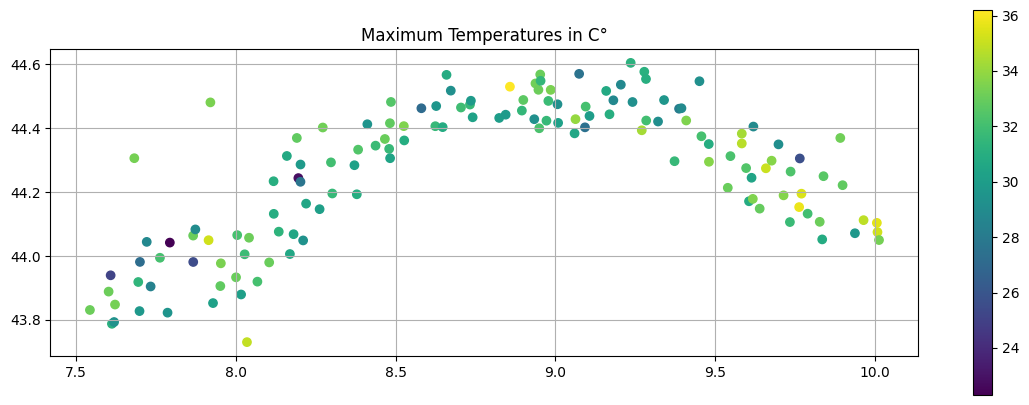

In [21]:
values = day_data.groupby('geography')['averageTemp'].max()

def parse_wkt_point(geom_string):
  # we have to parse this POINT (Lon Lat)
  try:
    m = re.search(r'(\d+\.?\d*)\s+(\d+\.?\d*)', geom_string)
    lon = m.group(1)
    lat = m.group(2)
    return lon, lat
  except:
    return None, None

xs = []
ys = []
for location in values.index:
    x, y = parse_wkt_point(location)
    xs.append(float(x))
    ys.append(float(y))
    
# actual plotting
plt.figure(figsize=(14,5))
plt.axes().set_aspect('equal')
plt.title('Maximum Temperatures in C°')
plt.grid()
plt.scatter(xs, ys, c=values, marker="o", cmap="viridis")
plt.colorbar()
plt.show()

Another common use case is to retrieve the n nearest data points to a certain location. This is very common in modelling applications, where we are interested in running a given model over weather data representative of a give location within a certain time frame.
The `getNearestStationData` is meant to do precisely that, allowing users to retrieve data from the nearest n stations to a given geometry, be it a point, or a polygon, or whatever WKT geometry we may extract from a cartography.
This method allows to specify how many stations we'd like to include in our search with the *limit* parameter, which can be any positive integer number.

In the following cell we extract data from the single nearest station to a certain point.

In [8]:
data = {"startTime":"2021-06-14",
"endTime":"2021-06-20",
"timeStep":"hour",
"wkt":"POINT(9.3 44.5)",
"limit":1
}
# call the service
r = call_restful_api('getNearestStationData', data,key = SERVICE_KEY, base_url = SERVICE_URL, method= 'POST')
# read the response into a data table
day_data = pd.read_csv(StringIO(r))
day_data

,date,seriesID,averageTemp,precipitation,idGroup,idCode,stationName,country,elevation,geography
0,2021-06-14 00:00:00+02:00,11,12.8,0.0,regione-liguria,CABAN,Cabanne,IT,809.0,POINT (9.3408 44.4883)
1,2021-06-14 01:00:00+02:00,11,11.9,0.0,regione-liguria,CABAN,Cabanne,IT,809.0,POINT (9.3408 44.4883)
2,2021-06-14 02:00:00+02:00,11,11.3,0.0,regione-liguria,CABAN,Cabanne,IT,809.0,POINT (9.3408 44.4883)
3,2021-06-14 03:00:00+02:00,11,10.3,0.0,regione-liguria,CABAN,Cabanne,IT,809.0,POINT (9.3408 44.4883)
4,2021-06-14 04:00:00+02:00,11,9.8,0.0,regione-liguria,CABAN,Cabanne,IT,809.0,POINT (9.3408 44.4883)
...,...,...,...,...,...,...,...,...,...,...
139,2021-06-19 20:00:00+02:00,11,19.9,0.0,regione-liguria,CABAN,Cabanne,IT,809.0,POINT (9.3408 44.4883)
140,2021-06-19 21:00:00+02:00,11,18.5,0.0,regione-liguria,CABAN,Cabanne,IT,809.0,POINT (9.3408 44.4883)
141,2021-06-19 22:00:00+02:00,11,16.5,0.0,regione-liguria,CABAN,Cabanne,IT,809.0,POINT (9.3408 44.4883)
142,2021-06-19 23:00:00+02:00,11,15.2,0.0,regione-liguria,CABAN,Cabanne,IT,809.0,POINT (9.3408 44.4883)


We can visualize such data with a scatterplot. In the following cell, we plot the hourly average temperature.

<Axes: xlabel='date'>

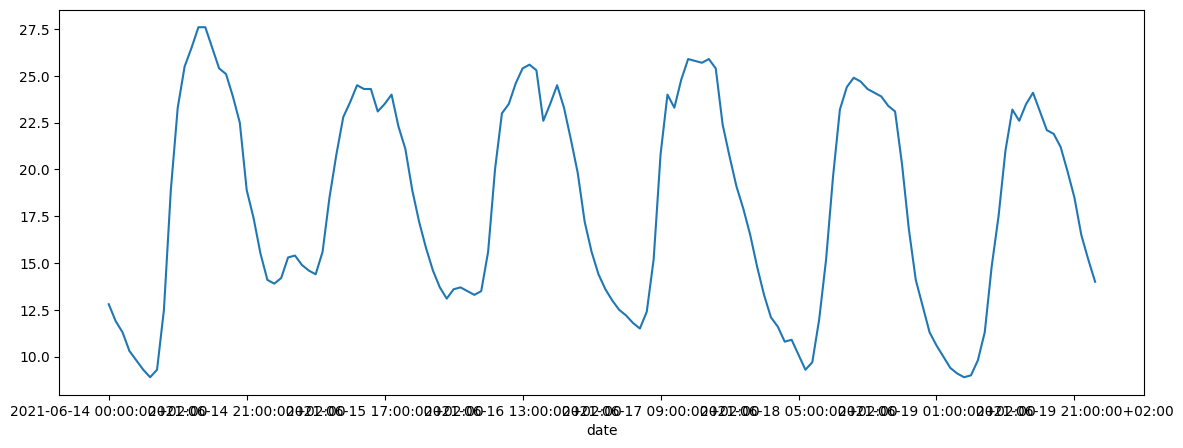

In [9]:
day_data.index = day_data['date']
plt.figure(figsize = (14, 5))
day_data['averageTemp'].plot()

# SIAN historical weather series
The CREA weather API allows access to the historical SIAN data series too. Accessing it requires to invoke the `getRasterData` function including the additional `group` paramter set to `sian`.

The following cell provides an invocation example. We are using the very same polygon we used in the first request. Notice that, since the SIAN series end with the 2017 year, we have to ask for a different time frame. Let's still pick the same days, but 20 years prior.

In [10]:
data = {"startTime":"2002-06-14",
"endTime":"2002-06-20",
"timeStep":"day",
"wkt":polygon_string,
"group":"sian"
}
# call the service
r = call_restful_api('getRasterData', data,key = SERVICE_KEY, base_url = SERVICE_URL, method= 'POST')
# read the response into a data table
day_data = pd.read_csv(StringIO(r))
day_data

,date,seriesID,maxTemp,minTemp,precipitation,idGroup,idCode,country,geography
0,2002-06-14 00:00:00+02:00,5,25.620001,15.720000,0.00,sian,2195.0,IT,POINT (9.18 44.7)
1,2002-06-15 00:00:00+02:00,5,26.059999,17.270000,0.00,sian,2195.0,IT,POINT (9.18 44.7)
2,2002-06-16 00:00:00+02:00,5,26.850000,17.510000,0.00,sian,2195.0,IT,POINT (9.18 44.7)
3,2002-06-17 00:00:00+02:00,5,27.719999,17.889999,0.01,sian,2195.0,IT,POINT (9.18 44.7)
4,2002-06-18 00:00:00+02:00,5,28.180000,19.490000,0.01,sian,2195.0,IT,POINT (9.18 44.7)
...,...,...,...,...,...,...,...,...,...
786,2002-06-16 00:00:00+02:00,5,27.139999,15.740000,0.00,sian,3072.0,IT,POINT (10.16 43.7)
787,2002-06-17 00:00:00+02:00,5,28.180000,16.600000,0.07,sian,3072.0,IT,POINT (10.16 43.7)
788,2002-06-18 00:00:00+02:00,5,29.520000,19.549999,0.00,sian,3072.0,IT,POINT (10.16 43.7)
789,2002-06-19 00:00:00+02:00,5,30.660000,21.950001,2.81,sian,3072.0,IT,POINT (10.16 43.7)


Now we can  work on the retrieved data, for instance we can extract for all cells the highes temperature, and plot it on its geographical coordinates. We can clearly see the raster grid and the temperature gradients.

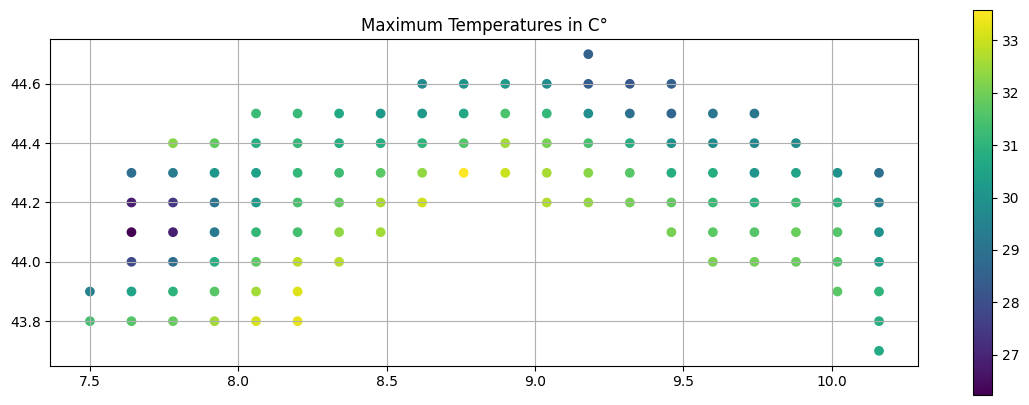

In [11]:
values = day_data.groupby('geography')['maxTemp'].max()

xs = []
ys = []
for location in values.index:
    x, y = parse_wkt_point(location)
    xs.append(float(x))
    ys.append(float(y))
    
# actual plotting
plt.figure(figsize=(14,5))
plt.axes().set_aspect('equal')
plt.title('Maximum Temperatures in C°')
plt.grid()
plt.scatter(xs, ys, c=values, marker="o", cmap="viridis")
plt.colorbar()
plt.show()

# The Era5 API
CREA mirrors a portion of Copernicus' [ERA5 dataset](https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-land?tab=form) relevant to our modelling activities.

The Era5 API shares the same interface with the above described `getStationData` API, but sits on another base address, hence depending on your user privileges may require you to register a different key. Here is an example of its invocation.

In [12]:
era5_service_url = 'https://api.anaee.eu/era5-data-access'
era5_get_method = 'GetEraData'

data = {"startTime":"2022-06-14",
"endTime":"2022-06-20",
"timeStep":"hour",
"wkt":polygon_string
}
# call the service
r = call_restful_api(era5_get_method, data,key = SERVICE_KEY, base_url =era5_service_url, method= 'POST')
# read the response into a data table
day_data = pd.read_csv(StringIO(r))
day_data

,station_id,idGroup,Country,firstRecord,lastRecord,Elevation,Latitude,Longitude,nuts1,nuts2,...,Date,date_index,d2m,t2m,u10,v10,ssrd,tp,rh,windspeed
0,9.25-44.50,Era5,Italia,1981-01-01 00:00:00+00:00,2024-03-07 23:00:00+00:00,695.173099,44.5,9.25,Nord-Ovest,Liguria,...,2022-06-15 00:00:00+00:00,2022-06-15 00:00:00+00:00,17.401216,22.436245,-1.090952,-1.056438,-2.328306e-10,0.000003,0.731808,1.518630
1,9.25-44.50,Era5,Italia,1981-01-01 00:00:00+00:00,2024-03-07 23:00:00+00:00,695.173099,44.5,9.25,Nord-Ovest,Liguria,...,2022-06-15 01:00:00+00:00,2022-06-15 01:00:00+00:00,16.798729,22.467356,-0.725302,-0.634488,-2.328306e-10,0.000008,0.703069,0.963659
2,9.25-44.50,Era5,Italia,1981-01-01 00:00:00+00:00,2024-03-07 23:00:00+00:00,695.173099,44.5,9.25,Nord-Ovest,Liguria,...,2022-06-15 02:00:00+00:00,2022-06-15 02:00:00+00:00,16.472291,21.471803,-0.559267,-0.496708,-2.328306e-10,0.000014,0.731781,0.747997
3,9.25-44.50,Era5,Italia,1981-01-01 00:00:00+00:00,2024-03-07 23:00:00+00:00,695.173099,44.5,9.25,Nord-Ovest,Liguria,...,2022-06-15 03:00:00+00:00,2022-06-15 03:00:00+00:00,16.890745,20.795736,-0.576990,-0.111117,-2.328306e-10,0.000000,0.783378,0.587592
4,9.25-44.50,Era5,Italia,1981-01-01 00:00:00+00:00,2024-03-07 23:00:00+00:00,695.173099,44.5,9.25,Nord-Ovest,Liguria,...,2022-06-15 04:00:00+00:00,2022-06-15 04:00:00+00:00,16.759294,21.041034,-0.976220,0.390248,6.871555e+03,0.000000,0.765228,1.051332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,7.75-44.00,Era5,Italia,1981-01-01 00:00:00+00:00,2024-03-07 23:00:00+00:00,875.047722,44.0,7.75,Nord-Ovest,Liguria,...,2022-06-20 19:00:00+00:00,2022-06-20 19:00:00+00:00,16.231297,22.761715,1.634634,1.432206,1.930282e+05,0.000000,0.666112,2.173302
3452,7.75-44.00,Era5,Italia,1981-01-01 00:00:00+00:00,2024-03-07 23:00:00+00:00,875.047722,44.0,7.75,Nord-Ovest,Liguria,...,2022-06-20 20:00:00+00:00,2022-06-20 20:00:00+00:00,15.808461,21.730264,1.945250,1.038960,2.498747e+03,0.000000,0.690412,2.205319
3453,7.75-44.00,Era5,Italia,1981-01-01 00:00:00+00:00,2024-03-07 23:00:00+00:00,875.047722,44.0,7.75,Nord-Ovest,Liguria,...,2022-06-20 21:00:00+00:00,2022-06-20 21:00:00+00:00,14.557480,20.238130,2.293177,0.683986,-2.328306e-10,0.000000,0.698288,2.393010
3454,7.75-44.00,Era5,Italia,1981-01-01 00:00:00+00:00,2024-03-07 23:00:00+00:00,875.047722,44.0,7.75,Nord-Ovest,Liguria,...,2022-06-20 22:00:00+00:00,2022-06-20 22:00:00+00:00,15.189543,19.077448,1.781080,-0.312046,-2.328306e-10,0.000000,0.781710,1.808209


As you can see variable names differ from the ones offered by the other services, as they reflect the Copernicus naming.

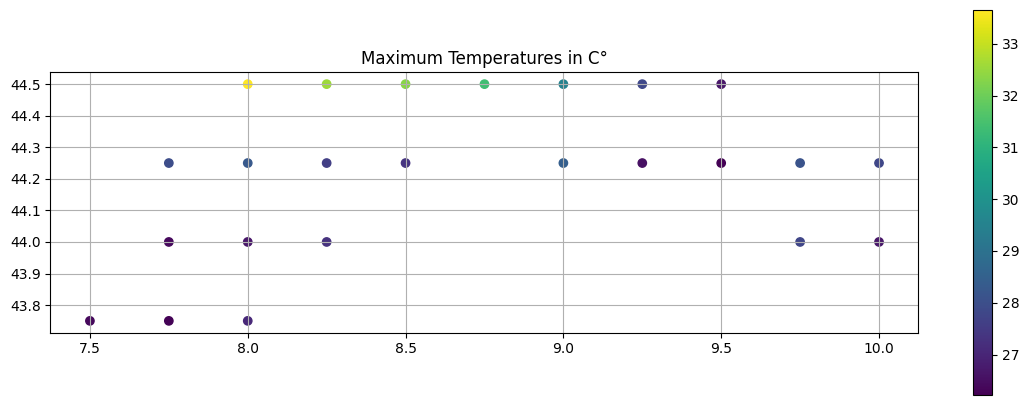

In [13]:
values = day_data.groupby('geometry')['t2m'].max()

def parse_wkt_point(geom_string):
  # we have to parse this POINT (Lon Lat)
  try:
    m = re.search(r'(\d+\.?\d*)\s+(\d+\.?\d*)', geom_string)
    lon = m.group(1)
    lat = m.group(2)
    return lon, lat
  except:
    return None, None

xs = []
ys = []
for location in values.index:
    x, y = parse_wkt_point(location)
    xs.append(float(x))
    ys.append(float(y))
    
# actual plotting
plt.figure(figsize=(14,5))
plt.axes().set_aspect('equal')
plt.title('Maximum Temperatures in C°')
plt.grid()
plt.scatter(xs, ys, c=values, marker="o", cmap="viridis")
plt.colorbar()
plt.show()

Finally, we can select a single point and plot its data.

<Axes: xlabel='Date'>

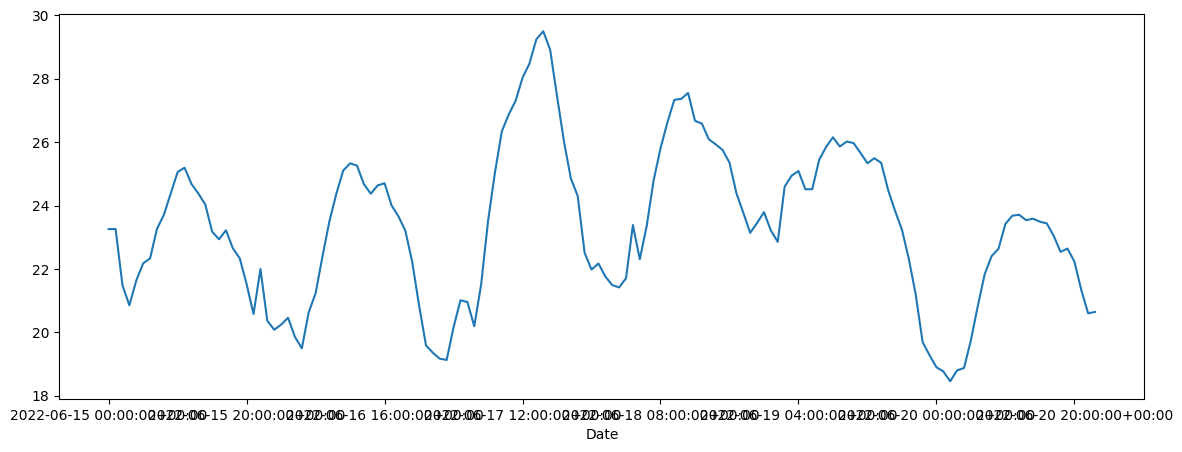

In [14]:
cell_data = day_data.loc[day_data['geometry'] == 'POINT(9.0 44.5)']
cell_data.index = cell_data['Date']
plt.figure(figsize = (14, 5))
cell_data['t2m'].plot()